# General Paired Off-line NIR Comparative Study

## Purpose

This notebook provides a general report workflow for paired off-line NIR comparative studies where the same physical sample or tablet is measured by both the old and changed NIR procedures. It is intended for synthetic demonstrations and planning workflows supporting Granule Assay NIR and Tablet Transmission NIR method modules.

## Regulatory/statistical basis

The paired comparison uses tested helper functions from `src/nir_cp/`. Paired accuracy equivalence is assessed using the confidence interval for the mean paired difference `new - old` against the predefined margin `+/-D_EQUIVALENCE_MARGIN`. Precision method selection is explicit. For final CP/GMP use, paired precision should use a CP-approved method and input source, such as known old-method variance or duplicate independent measurements. The observed SD-ratio option in this example is supportive/exploratory for heterogeneous paired samples unless justified.

The overall decision passes only when both predefined criteria pass.

## Input configuration

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

from nir_cp.notebook_export import export_notebook_pdf
from nir_cp.paired_comparison import paired_comparison_decision
from nir_cp.plots import (
    plot_bland_altman,
    plot_difference_vs_reference,
    plot_old_vs_new,
)
from nir_cp.report_equations import display_equation, display_equation_set
from nir_cp.report_tables import display_report_dataframe
from nir_cp.reporting_text import paired_decision_summary_text
from nir_cp.simulation import simulate_paired_comparison_success

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "examples").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "examples" / "paired_offline_nir_example.csv"

D_EQUIVALENCE_MARGIN = 0.50
K_PRECISION_RATIO = 2.50
ALPHA_ACCURACY = 0.05
ALPHA_PRECISION = 0.05
PRECISION_METHOD = "observed_sd_ratio_exploratory"
OLD_VARIANCE = None
ALLOW_EXPLORATORY_PRECISION_AS_PRIMARY = True
N_SIM = 1000
RANDOM_SEED = 12345
EXPORT_REPORT = True

METHOD_NAME = "Paired off-line NIR method"

## Load data

In [2]:
df = pd.read_csv(DATA_PATH)
display_report_dataframe(df, max_rows=10);
display_report_dataframe(df[["method_module", "sample_type", "batch_id"]].drop_duplicates().reset_index(drop=True));

sample_id,method_module,batch_id,strength,old_nir,new_nir,reference,sample_type,analyst,instrument_old,instrument_new,date
SYN-001,Off-line Granule Assay NIR,SYN-B001,100 mg,99.800,99.900,99.700,granule,A01,NIR-OLD-01,NIR-NEW-01,2026-01-12
SYN-002,Off-line Granule Assay NIR,SYN-B001,100 mg,100.400,100.500,100.300,granule,A01,NIR-OLD-01,NIR-NEW-01,2026-01-12
SYN-003,Off-line Granule Assay NIR,SYN-B001,100 mg,98.900,99.100,99.000,granule,A02,NIR-OLD-01,NIR-NEW-01,2026-01-12
SYN-004,Off-line Granule Assay NIR,SYN-B001,100 mg,101.100,101.000,101.200,granule,A02,NIR-OLD-01,NIR-NEW-01,2026-01-12
SYN-005,Off-line Granule Assay NIR,SYN-B002,100 mg,99.500,99.700,99.600,granule,A01,NIR-OLD-01,NIR-NEW-01,2026-01-13
SYN-006,Off-line Granule Assay NIR,SYN-B002,100 mg,100.700,100.600,100.800,granule,A01,NIR-OLD-01,NIR-NEW-01,2026-01-13
SYN-007,Off-line Granule Assay NIR,SYN-B002,100 mg,98.700,98.800,98.900,granule,A02,NIR-OLD-01,NIR-NEW-01,2026-01-13
SYN-008,Off-line Granule Assay NIR,SYN-B002,100 mg,101.400,101.500,101.300,granule,A02,NIR-OLD-01,NIR-NEW-01,2026-01-13
SYN-009,Off-line Granule Assay NIR,SYN-B003,100 mg,100.100,100.000,100.200,granule,A01,NIR-OLD-01,NIR-NEW-01,2026-01-14
SYN-010,Off-line Granule Assay NIR,SYN-B003,100 mg,99.200,99.300,99.100,granule,A01,NIR-OLD-01,NIR-NEW-01,2026-01-14


method_module,sample_type,batch_id
Off-line Granule Assay NIR,granule,SYN-B001
Off-line Granule Assay NIR,granule,SYN-B002
Off-line Granule Assay NIR,granule,SYN-B003
Off-line Tablet Transmission NIR,tablet,SYN-T001
Off-line Tablet Transmission NIR,tablet,SYN-T002
Off-line Tablet Transmission NIR,tablet,SYN-T003


'<table border="1" class="dataframe report-dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th>method_module</th>\n      <th>sample_type</th>\n      <th>batch_id</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <td>Off-line Granule Assay NIR</td>\n      <td>granule</td>\n      <td>SYN-B001</td>\n    </tr>\n    <tr>\n      <td>Off-line Granule Assay NIR</td>\n      <td>granule</td>\n      <td>SYN-B002</td>\n    </tr>\n    <tr>\n      <td>Off-line Granule Assay NIR</td>\n      <td>granule</td>\n      <td>SYN-B003</td>\n    </tr>\n    <tr>\n      <td>Off-line Tablet Transmission NIR</td>\n      <td>tablet</td>\n      <td>SYN-T001</td>\n    </tr>\n    <tr>\n      <td>Off-line Tablet Transmission NIR</td>\n      <td>tablet</td>\n      <td>SYN-T002</td>\n    </tr>\n    <tr>\n      <td>Off-line Tablet Transmission NIR</td>\n      <td>tablet</td>\n      <td>SYN-T003</td>\n    </tr>\n  </tbody>\n</table>'

# Statistical theory and decision rules

<!-- SVG equation metadata for tests: $$$$ \mu_D \bar{D} \sigma_N -->

## Study design

The same physical sample/tablet is measured with the current/old and changed/new NIR procedure. The paired difference is defined as:

In [ ]:
_ = display_equation(r"D_i = Y_{N,i} - Y_{O,i}")

Pairing removes between-sample variation from the accuracy comparison. This notebook calls tested functions under `src/nir_cp/` and does not implement independent pass/fail logic.

## Accuracy equivalence

The paired accuracy hypotheses are:

In [ ]:
_ = display_equation_set([
    r"H_0: |\mu_D| \ge d",
    r"H_A: |\mu_D| < d",
])

The sample mean and variance of the paired differences are:

In [ ]:
_ = display_equation_set([
    r"\bar{D} = \frac{1}{n}\sum_{i=1}^{n}D_i",
    r"s_D^2 = \frac{\sum_{i=1}^{n}(D_i-\bar{D})^2}{n-1}",
])

The confidence interval used for paired accuracy is:

In [ ]:
_ = display_equation(r"\bar{D} \pm t_{1-\alpha,n-1}\frac{s_D}{\sqrt{n}}")

For `alpha = 0.05`, this is a two-sided 90% confidence interval used for TOST equivalence. The accuracy criterion is met if the full confidence interval is contained within:

In [ ]:
_ = display_equation(r"[-d, +d]")

## Precision noninferiority

The precision hypotheses are:

In [ ]:
_ = display_equation_set([
    r"H_0: \frac{\sigma_N}{\sigma_O} \ge k",
    r"H_A: \frac{\sigma_N}{\sigma_O} < k",
])

Precision assessment depends on the study design and available variance information. For heterogeneous paired samples, the preferred primary precision method should be either paired design with known/historical old-method variance, or duplicate independent measurements for old and new procedures. The observed raw SD ratio across heterogeneous paired samples is supportive/exploratory unless explicitly justified in the CP.

For the known old-variance option, the upper bound is:

In [ ]:
_ = display_equation(r"U = \sqrt{\frac{(n-1)s_D^2}{\sigma_O^2\chi^2_{\alpha,n-1}} - 1}")

with decision rule:

In [ ]:
_ = display_equation(r"U < k")

For the duplicate-measurement option, the duplicate scaled differences are:

In [ ]:
_ = display_equation_set([
    r"d_{O,i} = \frac{Y_{O,i,1}-Y_{O,i,2}}{\sqrt{2}}",
    r"d_{N,i} = \frac{Y_{N,i,1}-Y_{N,i,2}}{\sqrt{2}}",
])

and an F-based one-sided upper confidence bound is used for `sigma_N / sigma_O`.

> Precision method note: the observed SD-ratio calculation shown in this example is supportive/exploratory for heterogeneous paired samples unless specifically justified in the CP. Final CP/GMP use should apply the CP-approved primary precision method.

## Values used in this notebook

The table below is generated from the notebook variables and input data. Calculations and final pass/fail decisions are performed by tested functions under `src/nir_cp/`.

In [ ]:
values_used = {
    "method name": METHOD_NAME,
    "precision_method": PRECISION_METHOD,
    "n": len(df),
    "d": D_EQUIVALENCE_MARGIN,
    "k": K_PRECISION_RATIO,
    "alpha_accuracy": ALPHA_ACCURACY,
    "alpha_precision": ALPHA_PRECISION,
    "random seed": RANDOM_SEED,
    "n_sim": N_SIM,
}
if OLD_VARIANCE is not None:
    values_used["old_variance"] = OLD_VARIANCE

display_report_dataframe(pd.DataFrame([values_used]), transpose_if_one_row=True);

## Data checks

In [3]:
required_columns = [
    "sample_id",
    "method_module",
    "batch_id",
    "strength",
    "old_nir",
    "new_nir",
    "reference",
    "sample_type",
    "analyst",
    "instrument_old",
    "instrument_new",
    "date",
]
missing_columns = sorted(set(required_columns) - set(df.columns))
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

if df[required_columns].isna().any().any():
    raise ValueError("Input data contain missing values in required columns.")

if df["sample_id"].duplicated().any():
    raise ValueError("sample_id values must be unique for this paired workflow.")

numeric_columns = ["old_nir", "new_nir", "reference"]
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="raise")

df["difference_new_minus_old"] = df["new_nir"] - df["old_nir"]
df["average_old_new"] = (df["old_nir"] + df["new_nir"]) / 2

display_report_dataframe(
    pd.DataFrame(
        {
            "n_pairs": [len(df)],
            "mean_old_nir": [df["old_nir"].mean()],
            "mean_new_nir": [df["new_nir"].mean()],
            "mean_difference_new_minus_old": [df["difference_new_minus_old"].mean()],
            "sd_old_nir": [df["old_nir"].std(ddof=1)],
            "sd_new_nir": [df["new_nir"].std(ddof=1)],
        }
    ),
    transpose_if_one_row=True,
);

,n_pairs,mean_old_nir,mean_new_nir,mean_difference_new_minus_old,sd_old_nir,sd_new_nir
0,24,99.995833,100.045833,0.05,0.859969,0.835089


## Paired accuracy equivalence

In [4]:
decision = paired_comparison_decision(
    old_values=df["old_nir"],
    new_values=df["new_nir"],
    d=D_EQUIVALENCE_MARGIN,
    k=K_PRECISION_RATIO,
    alpha_accuracy=ALPHA_ACCURACY,
    alpha_precision=ALPHA_PRECISION,
    precision_method=PRECISION_METHOD,
    old_variance=OLD_VARIANCE,
    allow_exploratory_precision_as_primary=ALLOW_EXPLORATORY_PRECISION_AS_PRIMARY,
)

accuracy = decision["accuracy"]
display_report_dataframe(
    pd.DataFrame(
        [
            {
                "pass": accuracy["pass"],
                "n": accuracy["n"],
                "mean_difference": accuracy["mean_difference"],
                "ci_confidence": accuracy["ci_confidence"],
                "lower": accuracy["lower"],
                "upper": accuracy["upper"],
                "d": accuracy["d"],
                "alpha": accuracy["alpha"],
            }
        ]
    ),
    transpose_if_one_row=True,
);

,pass,n,mean_difference,ci_confidence,lower,upper,d,alpha
0,True,24,0.05,0.9,0.014263,0.085737,0.5,0.05


## Precision noninferiority

In [5]:
precision = decision["precision"]
display_report_dataframe(
    pd.DataFrame(
        [
            {
                "pass": precision["pass"],
                "sd_old": precision["sd_old"],
                "sd_new": precision["sd_new"],
                "ratio_observed": precision["ratio_observed"],
                "upper_bound": precision["upper_bound"],
                "k": precision["k"],
                "alpha": precision["alpha"],
            }
        ]
    ),
    transpose_if_one_row=True,
);

,pass,sd_old,sd_new,ratio_observed,upper_bound,k,alpha
0,True,0.859969,0.835089,0.971068,1.378241,2.5,0.05


## Overall decision

In [6]:
summary_text = paired_decision_summary_text(decision, method_name=METHOD_NAME)
display(Markdown(summary_text))
display_report_dataframe(pd.DataFrame([{"overall_pass": decision["overall_pass"], "decision_text": decision["decision_text"]}]), transpose_if_one_row=True);

Paired off-line NIR method met the predefined criteria for paired accuracy equivalence and precision noninferiority. The paired mean difference (new - old) was 0.050, with a 90.0% confidence interval from 0.014 to 0.086; the predefined equivalence margin was +/-0.500. The upper confidence bound for the precision ratio (sigma_new / sigma_old) was 1.378, compared with the predefined limit k=2.500.

overall_pass,decision_text
True,The changed NIR method met the predefined paired accuracy equivalence and exploratory observed-SD precision criteria. This precision method is supportive/exploratory and is not the preferred USP <1010> paired precision method for heterogeneous samples unless justified.


'<table border="1" class="dataframe report-dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th>overall_pass</th>\n      <th>decision_text</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <td>True</td>\n      <td>The changed NIR method met the predefined paired accuracy equivalence and exploratory observed-SD precision criteria. This precision method is supportive/exploratory and is not the preferred USP &lt;1010&gt; paired precision method for heterogeneous samples unless justified.</td>\n    </tr>\n  </tbody>\n</table>'

## Supporting plots

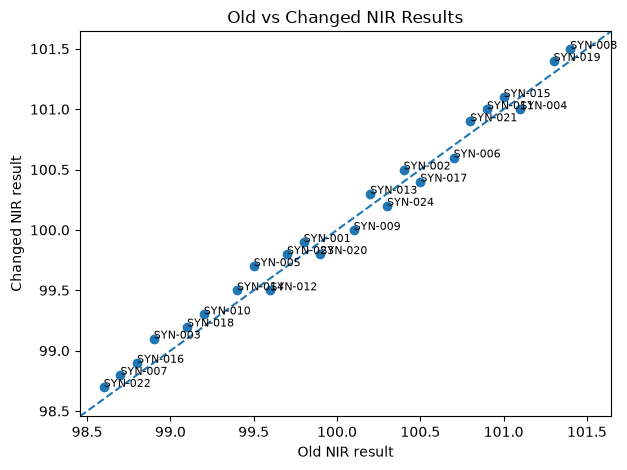

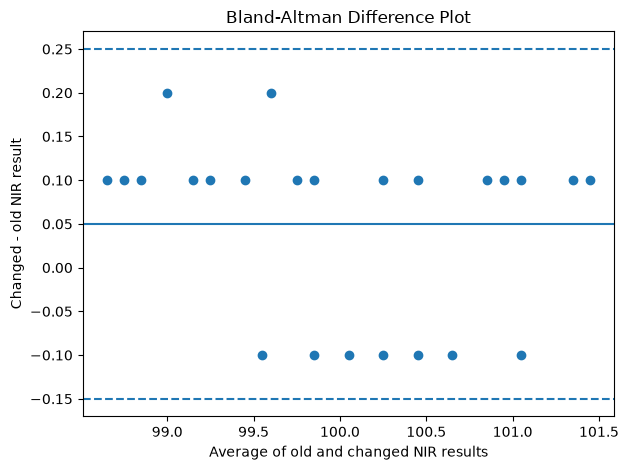

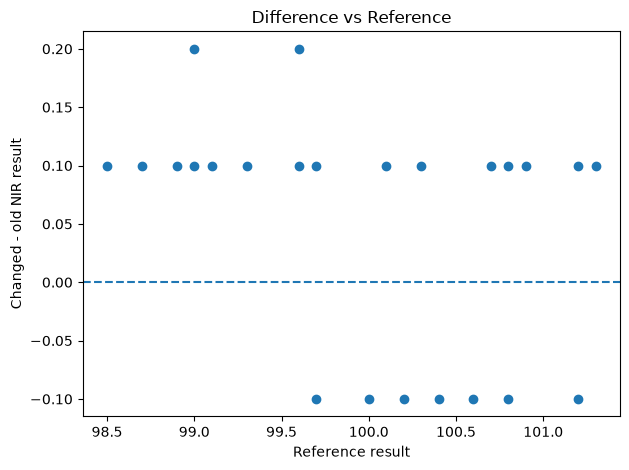

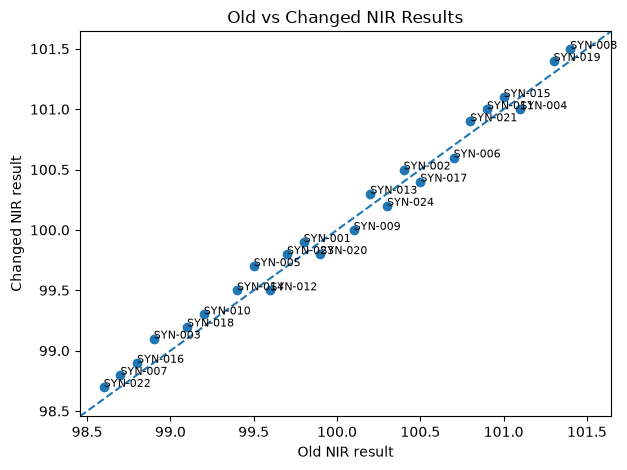

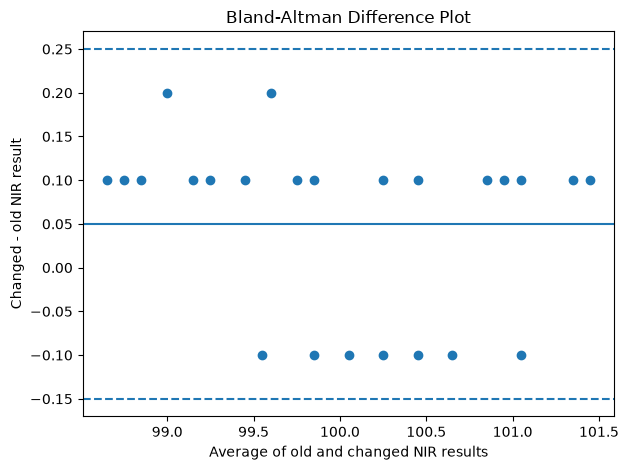

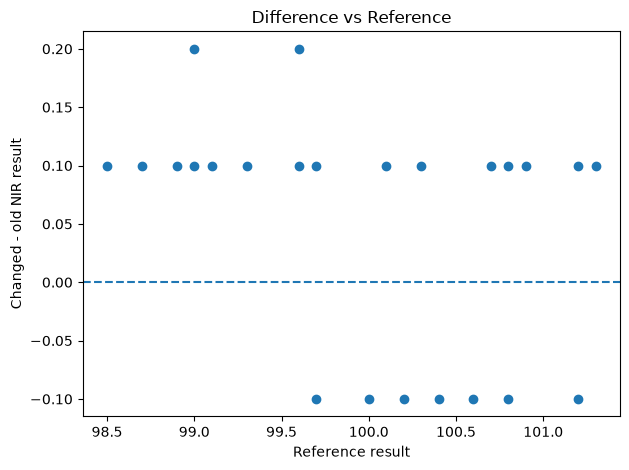

In [7]:
fig_old_new = plot_old_vs_new(df, sample_id_col="sample_id")
fig_bland_altman = plot_bland_altman(df)
fig_difference_reference = plot_difference_vs_reference(df)

display(fig_old_new)
display(fig_bland_altman)
display(fig_difference_reference)

## Probability-of-success simulation

In [8]:
simulation_result = simulate_paired_comparison_success(
    n=len(df),
    true_bias=float(df["difference_new_minus_old"].mean()),
    old_sd=float(df["old_nir"].std(ddof=1)),
    new_sd=float(df["new_nir"].std(ddof=1)),
    d=D_EQUIVALENCE_MARGIN,
    k=K_PRECISION_RATIO,
    n_sim=N_SIM,
    seed=RANDOM_SEED,
    alpha_accuracy=ALPHA_ACCURACY,
    alpha_precision=ALPHA_PRECISION,
)

display_report_dataframe(pd.DataFrame([simulation_result]), transpose_if_one_row=True);

n,true_bias,old_sd,new_sd,d,k,n_sim,seed,alpha_accuracy,alpha_precision,pass_accuracy_probability,pass_precision_probability,pass_both_probability,fail_accuracy_probability,fail_precision_probability
24,0.050,0.860,0.835,0.500,2.500,1000,12345,0.050,0.050,0.283,0.996,0.283,0.717,0.004


'<table border="1" class="dataframe report-dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th>n</th>\n      <th>true_bias</th>\n      <th>old_sd</th>\n      <th>new_sd</th>\n      <th>d</th>\n      <th>k</th>\n      <th>n_sim</th>\n      <th>seed</th>\n      <th>alpha_accuracy</th>\n      <th>alpha_precision</th>\n      <th>pass_accuracy_probability</th>\n      <th>pass_precision_probability</th>\n      <th>pass_both_probability</th>\n      <th>fail_accuracy_probability</th>\n      <th>fail_precision_probability</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <td>24</td>\n      <td>0.050</td>\n      <td>0.860</td>\n      <td>0.835</td>\n      <td>0.500</td>\n      <td>2.500</td>\n      <td>1000</td>\n      <td>12345</td>\n      <td>0.050</td>\n      <td>0.050</td>\n      <td>0.283</td>\n      <td>0.996</td>\n      <td>0.283</td>\n      <td>0.717</td>\n      <td>0.004</td>\n    </tr>\n  </tbody>\n</table>'

## Export report

Set `EXPORT_REPORT = True` in the input configuration section to export the notebook to PDF. Export is disabled by default so routine notebook execution does not create report files automatically.

In [9]:
if EXPORT_REPORT:
    notebook_path = PROJECT_ROOT / "notebooks" / "01_general_paired_offline_nir_comparison.ipynb"
    pdf_path = PROJECT_ROOT / "reports" / "pdf" / "01_general_paired_offline_nir_comparison.pdf"
    exported_pdf = export_notebook_pdf(notebook_path, pdf_path, hide_code=True, keep_html=True)
    display(Markdown(f"Exported PDF report: `{exported_pdf}`"))
else:
    display(Markdown("PDF export skipped because `EXPORT_REPORT` is `False`."))

Exported PDF report: `c:\Users\Erik\Documents\Projects\nir-cp-comparability\reports\pdf\01_general_paired_offline_nir_comparison.pdf`